# Regresión Lineal - Precios de Propiedades en CABA

Implementación de regresión lineal desde scratch para predecir el precio de propiedades en CABA.

## Features y target

**Features (X)**: `metros`, `ambientes`, `banos`, `expensas`    
**Target (y)**: `precio` en USD

## Estructura
1. Setup e imports  
2. Carga                                               
3. Split train/val/test         
4. Feature scaling (z-score normalization)                        
5. Regresión lineal desde scratch (función de costo + gradient descent)
6. Evaluación (MSE, RMSE, MAE, R²)

### 1. Setup/Imports

In [11]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

### 2. Carga

In [12]:
df = pd.read_csv("../data/processed/zonaprop_clean.csv")
print(f"Filas: {len(df):,}")
df[["precio", "metros", "ambientes", "banos", "expensas"]].head()

Filas: 32,585


,precio,metros,ambientes,banos,expensas
0,530000.0,172.0,4.0,3.0,770000
1,170000.0,73.0,4.0,1.0,0
2,120000.0,54.0,3.0,1.0,260000
3,220000.0,68.0,3.0,2.0,380073
4,84100.0,55.0,1.0,1.0,110000


### 3. Split train/val/test

In [13]:
features = ["metros", "ambientes", "banos", "expensas"]

X = df[features].values
y = df["precio"].values

np.random.seed(42)
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]
n = len(X)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)
X_train, y_train = X[:n_train],           y[:n_train]
X_val,   y_val   = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test,  y_test  = X[n_train+n_val:],     y[n_train+n_val:]
print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")

Train: (22809, 4)
Val:   (4887, 4)
Test:  (4889, 4)


### 4. Feature scaling (Z-score normalization)
  
Transformamos cada feature para que tenga media 0 y desvío estándar 1.
Los parámetros μ y σ se calculan solo sobre train y se aplican a val y test para no filtrar información futura al modelo.

  $$x' = \frac{x - \mu}{\sigma}$$


In [14]:
mu    = X_train.mean(axis=0)
sigma = X_train.std(axis=0)

X_train_s = (X_train - mu) / sigma
X_val_s   = (X_val   - mu) / sigma
X_test_s  = (X_test  - mu) / sigma

print("Medias por feature (train escalado):")
print(X_train_s.mean(axis=0).round(6))
print("\nDesvíos por feature (train escalado):")
print(X_train_s.std(axis=0).round(6))

Medias por feature (train escalado):
[ 0.  0. -0.  0.]

Desvíos por feature (train escalado):
[1. 1. 1. 1.]


  ### 5. Regresión lineal desde scratch

  El modelo lineal predice el precio como una combinación de las features:
  
  $$\hat{y} = w_1x_1 + w_2x_2 + ... + w_nx_n + b = \mathbf{w}\mathbf{X} + b$$
  
  donde $\mathbf{w}$ son los pesos de cada feature y $b$ el bias. El objetivo es encontrar
  los valores de $\mathbf{w}$ y $b$ que minimicen el error entre las predicciones y los
  valores reales.
  
  Para eso se usan tres funciones encadenadas:
  
  **`compute_cost`** — mide qué tan mal está el modelo en un momento dado usando el error
  cuadrático medio:
  
  $$J(\mathbf{w}, b) = \frac{1}{2m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})^2$$
  
  **`compute_gradient`** — calcula en qué dirección mover $\mathbf{w}$ y $b$ para reducir
  $J$. Son las derivadas parciales de la función de costo:
  
  $$\frac{\partial J}{\partial \mathbf{w}} = \frac{1}{m} \mathbf{X}^T (\hat{y} - y) \qquad
  \frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})$$
  
  **`gradient_descent`** — el loop principal. En cada iteración usa el gradiente para
  actualizar los parámetros moviéndolos en la dirección contraria al error:
  
  $$w := w - \alpha \frac{\partial J}{\partial w} \qquad b := b - \alpha \frac{\partial
  J}{\partial b}$$
  
  $\alpha$ es el learning rate y controla el tamaño de cada paso. Al final de todas las
  iteraciones devuelve $\mathbf{w}$ y $b$ óptimos.
  


#### 5.1 `compute_cost`

In [15]:
def compute_cost(X, y, w, b): 
    m = X.shape[0]
    y_hat = X @ w +b 
    cost = (1 / (2 * m)) * np.sum((y_hat - y) ** 2) 
    return cost

#### 5.2 `compute_gradient`

In [16]:
def compute_gradient(X, y, w, b):
     m = len(y)
     y_hat = X @ w + b
     error = y_hat - y
 
     dw = (1 / m) * X.T @ error
     db = (1 / m) * np.sum(error)
     return dw, db

#### 5.3 `gradient_descent`

In [17]:
def gradient_descent(X, y, w_init, b_init, alpha, num_iters):
    """
    Runs gradient descent to learn w and b.

    Args:
        X        (ndarray): training data, shape (m, n)
        y        (ndarray): target values, shape (m,)
        w_init   (ndarray): initial weights, shape (n,)
        b_init   (float):   initial bias
        alpha    (float):   learning rate
        num_iters (int):    number of iterations

    Returns:
        w             (ndarray): optimized weights
        b             (float):   optimized bias
        cost_history  (list):    cost every 100 iterations
        params_history (list):   list of {"w": ..., "b": ...} every 100 iterations
    """
    w = w_init.copy()
    b = b_init
    cost_history = []
    params_history = []

    for i in range(num_iters):
        dw, db = compute_gradient(X, y, w, b)
        w = w - alpha * dw
        b = b - alpha * db

        if i % 100 == 0:
            cost_history.append(compute_cost(X, y, w, b))
            params_history.append({"w": w.copy(), "b": b})

    return w, b, cost_history, params_history

In [18]:
w_init = np.zeros(X_train_s.shape[1])
b_init = 0.0
alpha = 0.1
num_iters = 1000

w, b, cost_history, params_history = gradient_descent(
    X_train_s, y_train, w_init, b_init, alpha, num_iters
)

print("Evolución del costo:")
for i, cost in enumerate(cost_history):
    print(f"  iter {i * 100:>5}: J = {cost:,.2f}")

print("\nParámetros finales:")
for name, val in zip(["metros", "ambientes", "banos", "expensas"], w):
    print(f"  w_{name}: {val:,.2f}")
print(f"  b:        {b:,.2f}")

Evolución del costo:
  iter     0: J = 57,434,348,165.88
  iter   100: J = 15,178,403,296.08
  iter   200: J = 15,164,347,986.68
  iter   300: J = 15,164,239,888.71
  iter   400: J = 15,164,239,046.13
  iter   500: J = 15,164,239,039.56
  iter   600: J = 15,164,239,039.51
  iter   700: J = 15,164,239,039.51
  iter   800: J = 15,164,239,039.51
  iter   900: J = 15,164,239,039.51

Parámetros finales:
  w_metros: 143,764.15
  w_ambientes: -42,618.09
  w_banos: 85,193.17
  w_expensas: 37,306.28
  b:        276,540.77


#### Curva de aprendizaje

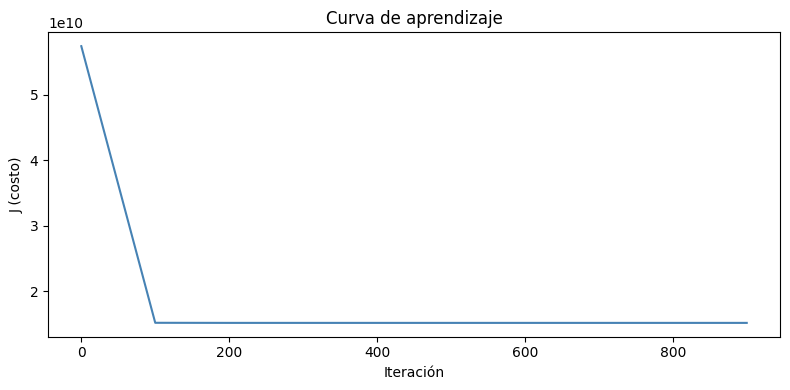

In [19]:
iters = [i * 100 for i in range(len(cost_history))]

plt.figure(figsize=(8, 4))
plt.plot(iters, cost_history, color="steelblue")
plt.xlabel("Iteración")
plt.ylabel("J (costo)")
plt.title("Curva de aprendizaje")
plt.tight_layout()
plt.show()

### 6. Evaluación

Con el modelo entrenado, medimos qué tan bien generaliza usando las métricas estándar de regresión:

- **MSE** — promedio de los errores al cuadrado; penaliza errores grandes
- **RMSE** — raíz del MSE, en la misma unidad que el target (USD); más interpretable
- **MAE** — promedio del error absoluto; más robusto a outliers que el RMSE
- **R²** — proporción de la varianza explicada por el modelo. 1 = perfecto, 0 = no mejor que predecir la media

Evaluamos sobre los tres sets para confirmar que el modelo generaliza.

In [20]:
def evaluate(X, y, w, b):
    y_hat = X @ w + b
    errors = y_hat - y
    mse  = np.mean(errors ** 2)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(errors))
    r2   = 1 - np.sum(errors ** 2) / np.sum((y - y.mean()) ** 2)
    return {"MSE": mse, "RMSE": rmse, "MAE": mae, "R²": r2}

sets = {"Train": (X_train_s, y_train), "Val": (X_val_s, y_val), "Test": (X_test_s, y_test)}
for name, (X_s, y_s) in sets.items():
    m = evaluate(X_s, y_s, w, b)
    print(f"{name:5s}  RMSE={m['RMSE']:>10,.0f} USD  MAE={m['MAE']:>10,.0f} USD  R²={m['R²']:.4f}")

Train  RMSE=   174,151 USD  MAE=    98,390 USD  R²=0.5500
Val    RMSE=   171,753 USD  MAE=    96,885 USD  R²=0.5546
Test   RMSE=   167,361 USD  MAE=    96,184 USD  R²=0.5379
